In [12]:
# Rainfall Amount PREDICTIONS USING Simple Linear REGRESSION 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
df = pd.read_csv(r'C:\Users\OM\Downloads\rainfall in india 1901-2015.csv')

In [14]:
df

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4111,LAKSHADWEEP,2011,5.1,2.8,3.1,85.9,107.2,153.6,350.2,254.0,255.2,117.4,184.3,14.9,1533.7,7.9,196.2,1013.0,316.6
4112,LAKSHADWEEP,2012,19.2,0.1,1.6,76.8,21.2,327.0,231.5,381.2,179.8,145.9,12.4,8.8,1405.5,19.3,99.6,1119.5,167.1
4113,LAKSHADWEEP,2013,26.2,34.4,37.5,5.3,88.3,426.2,296.4,154.4,180.0,72.8,78.1,26.7,1426.3,60.6,131.1,1057.0,177.6
4114,LAKSHADWEEP,2014,53.2,16.1,4.4,14.9,57.4,244.1,116.1,466.1,132.2,169.2,59.0,62.3,1395.0,69.3,76.7,958.5,290.5


In [15]:
df.head()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
0,ANDAMAN & NICOBAR ISLANDS,1901,49.2,87.1,29.2,2.3,528.8,517.5,365.1,481.1,332.6,388.5,558.2,33.6,3373.2,136.3,560.3,1696.3,980.3
1,ANDAMAN & NICOBAR ISLANDS,1902,0.0,159.8,12.2,0.0,446.1,537.1,228.9,753.7,666.2,197.2,359.0,160.5,3520.7,159.8,458.3,2185.9,716.7
2,ANDAMAN & NICOBAR ISLANDS,1903,12.7,144.0,0.0,1.0,235.1,479.9,728.4,326.7,339.0,181.2,284.4,225.0,2957.4,156.7,236.1,1874.0,690.6
3,ANDAMAN & NICOBAR ISLANDS,1904,9.4,14.7,0.0,202.4,304.5,495.1,502.0,160.1,820.4,222.2,308.7,40.1,3079.6,24.1,506.9,1977.6,571.0
4,ANDAMAN & NICOBAR ISLANDS,1905,1.3,0.0,3.3,26.9,279.5,628.7,368.7,330.5,297.0,260.7,25.4,344.7,2566.7,1.3,309.7,1624.9,630.8


In [16]:
df.tail()

,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
4111,LAKSHADWEEP,2011,5.1,2.8,3.1,85.9,107.2,153.6,350.2,254.0,255.2,117.4,184.3,14.9,1533.7,7.9,196.2,1013.0,316.6
4112,LAKSHADWEEP,2012,19.2,0.1,1.6,76.8,21.2,327.0,231.5,381.2,179.8,145.9,12.4,8.8,1405.5,19.3,99.6,1119.5,167.1
4113,LAKSHADWEEP,2013,26.2,34.4,37.5,5.3,88.3,426.2,296.4,154.4,180.0,72.8,78.1,26.7,1426.3,60.6,131.1,1057.0,177.6
4114,LAKSHADWEEP,2014,53.2,16.1,4.4,14.9,57.4,244.1,116.1,466.1,132.2,169.2,59.0,62.3,1395.0,69.3,76.7,958.5,290.5
4115,LAKSHADWEEP,2015,2.2,0.5,3.7,87.1,133.1,296.6,257.5,146.4,160.4,165.4,231.0,159.0,1642.9,2.7,223.9,860.9,555.4


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 4115
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SUBDIVISION  4116 non-null   object 
 1   YEAR         4116 non-null   int64  
 2   JAN          4112 non-null   float64
 3   FEB          4113 non-null   float64
 4   MAR          4110 non-null   float64
 5   APR          4112 non-null   float64
 6   MAY          4113 non-null   float64
 7   JUN          4111 non-null   float64
 8   JUL          4109 non-null   float64
 9   AUG          4112 non-null   float64
 10  SEP          4110 non-null   float64
 11  OCT          4109 non-null   float64
 12  NOV          4105 non-null   float64
 13  DEC          4106 non-null   float64
 14  ANNUAL       4090 non-null   float64
 15  Jan-Feb      4110 non-null   float64
 16  Mar-May      4107 non-null   float64
 17  Jun-Sep      4106 non-null   float64
 18  Oct-Dec      4103 non-null   float64
dtypes: flo

In [18]:
df.describe()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
count,4116.000000,4112.000000,4113.000000,4110.000000,4112.000000,4113.000000,4111.000000,4109.000000,4112.000000,4110.000000,4109.000000,4105.000000,4106.000000,4090.000000,4110.000000,4107.000000,4106.000000,4103.000000
mean,1958.218659,18.957320,21.805325,27.359197,43.127432,85.745417,230.234444,347.214334,290.263497,197.361922,95.507009,39.866163,18.870580,1411.008900,40.747786,155.901753,1064.724769,154.100487
std,33.140898,33.585371,35.909488,46.959424,67.831168,123.234904,234.710758,269.539667,188.770477,135.408345,99.519134,68.685410,42.369611,903.846565,59.308277,201.316965,707.741531,166.942660
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,62.300000,0.000000,0.000000,57.400000,0.000000
25%,1930.000000,0.600000,0.600000,1.000000,3.000000,8.600000,70.350000,175.600000,155.975000,100.525000,14.600000,0.700000,0.100000,804.500000,4.100000,24.050000,573.850000,34.200000
50%,1958.000000,6.000000,6.700000,7.800000,15.700000,36.600000,138.700000,284.800000,259.400000,173.900000,65.200000,9.500000,3.000000,1121.300000,19.200000,74.800000,881.100000,98.200000
75%,1987.000000,22.200000,26.800000,31.300000,49.950000,97.200000,305.150000,418.400000,377.800000,265.800000,148.400000,46.100000,17.500000,1644.775000,50.375000,196.950000,1288.175000,213.500000
max,2015.000000,583.700000,403.500000,605.600000,595.100000,1168.600000,1609.900000,2362.800000,1664.600000,1222.000000,948.300000,648.900000,617.500000,6331.100000,699.500000,1745.800000,4536.900000,1252.500000


In [19]:
corr = df.corr()
corr

C:\Users\OM\AppData\Local\Temp\ipykernel_5652\2438084875.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr()


,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec
YEAR,1.000000,-0.056235,-0.022144,0.020338,0.008007,0.003594,-0.013594,-0.016240,0.006442,-0.006670,0.002406,-0.018776,-0.019139,-0.008044,-0.044653,0.010637,-0.009418,-0.010155
JAN,-0.056235,1.000000,0.456183,0.398502,0.209302,0.129622,-0.033725,-0.051642,0.011952,0.024289,0.012374,0.067281,0.219701,0.105696,0.842390,0.242256,-0.022748,0.090932
FEB,-0.022144,0.456183,1.000000,0.579819,0.367114,0.203062,0.033703,0.016235,0.072159,0.080148,-0.004581,-0.023413,0.132570,0.181563,0.863815,0.382620,0.051066,0.021878
MAR,0.020338,0.398502,0.579819,1.000000,0.556856,0.362815,0.165857,0.097334,0.135071,0.178904,0.086187,0.008814,0.136328,0.322199,0.576366,0.642294,0.162055,0.090108
APR,0.008007,0.209302,0.367114,0.556856,1.000000,0.650595,0.457091,0.268097,0.256168,0.382525,0.368886,0.165642,0.132892,0.577573,0.340841,0.864172,0.394859,0.321407
MAY,0.003594,0.129622,0.203062,0.362815,0.650595,1.000000,0.567618,0.332283,0.329499,0.492378,0.529342,0.351931,0.250112,0.698013,0.196168,0.915019,0.496164,0.523684
JUN,-0.013594,-0.033725,0.033703,0.165857,0.457091,0.567618,1.000000,0.741285,0.655142,0.551890,0.490393,0.229718,0.088782,0.891303,0.001016,0.538562,0.893968,0.409050
JUL,-0.016240,-0.051642,0.016235,0.097334,0.268097,0.332283,0.741285,1.000000,0.686662,0.513067,0.299221,0.042671,-0.019427,0.812279,-0.019157,0.313726,0.907723,0.190400
AUG,0.006442,0.011952,0.072159,0.135071,0.256168,0.329499,0.655142,0.686662,1.000000,0.497037,0.250600,0.017488,0.001648,0.759304,0.050918,0.318347,0.840352,0.156293
SEP,-0.006670,0.024289,0.080148,0.178904,0.382525,0.492378,0.551890,0.513067,0.497037,1.000000,0.384138,0.153465,0.109457,0.715135,0.062131,0.470032,0.701980,0.319832


In [10]:
df.isnull().sum()

SUBDIVISION     0
YEAR            0
JAN             4
FEB             3
MAR             6
APR             4
MAY             3
JUN             5
JUL             7
AUG             4
SEP             6
OCT             7
NOV            11
DEC            10
ANNUAL         26
Jan-Feb         6
Mar-May         9
Jun-Sep        10
Oct-Dec        13
dtype: int64

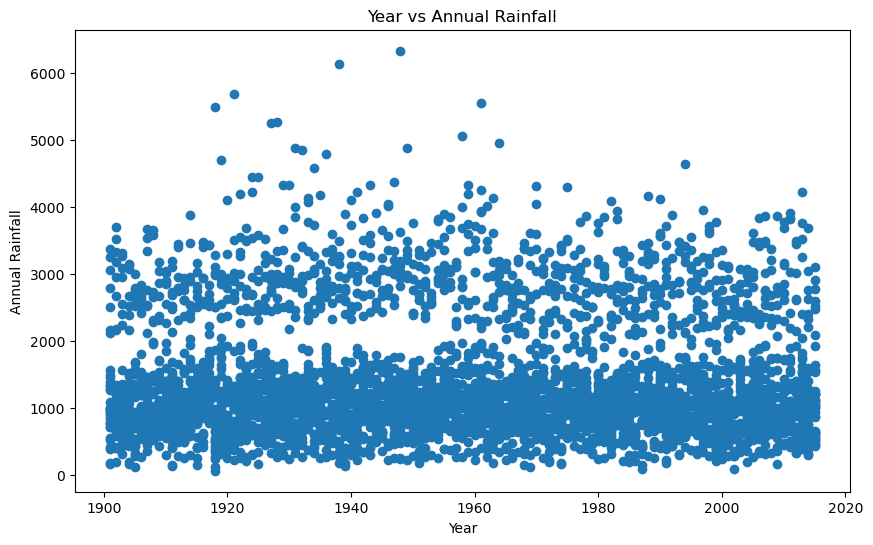

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df['YEAR'], df['ANNUAL'])
plt.xlabel('Year')
plt.ylabel('Annual Rainfall')
plt.title('Year vs Annual Rainfall')
plt.show()


In [25]:
# SELECT FEATURES and split data into x and y for training and testing
X = df[['YEAR']]
y = df['ANNUAL']

In [26]:
X

,YEAR
0,1901
1,1902
2,1903
3,1904
4,1905
...,...
4111,2011
4112,2012
4113,2013
4114,2014


In [27]:
y

0       3373.2
1       3520.7
2       2957.4
3       3079.6
4       2566.7
         ...  
4111    1533.7
4112    1405.5
4113    1426.3
4114    1395.0
4115    1642.9
Name: ANNUAL, Length: 4116, dtype: float64

In [50]:
data = df[['YEAR', 'ANNUAL']].dropna()

X = data[['YEAR']]
y = data['ANNUAL']

In [52]:
print(X.dtypes)
print(y.dtypes)

YEAR    int64
dtype: object
float64


In [53]:
# Spliting dataset into training and testing X and y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
X_train

,YEAR
2057,1911
2478,1987
2836,2000
2072,1926
1826,1910
...,...
1142,1916
1306,1965
872,1991
3521,1995


In [55]:
X_test

,YEAR
611,1960
764,1998
2031,2000
1013,1902
2531,1925
...,...
1433,1977
73,1979
2209,1948
3214,1918


In [56]:
y_train

2057     676.5
2478      92.7
2836     684.4
2072     913.8
1826     293.2
         ...  
1142    1114.2
1306    1305.7
872     1250.9
3521     843.4
3188    1099.2
Name: ANNUAL, Length: 3272, dtype: float64

In [57]:
y_test

611     1245.5
764     1357.1
2031     440.0
1013     905.2
2531    2305.1
         ...  
1433     740.1
73      1849.4
2209    1430.4
3214     554.7
233     2793.1
Name: ANNUAL, Length: 818, dtype: float64

In [58]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [59]:
y_pred = model.predict(X_test)

In [60]:
y_pred

array([1403.8415813 , 1400.46903201, 1400.29152941, 1408.98915655,
       1406.94787671, 1406.41536893, 1406.68162282, 1407.74663839,
       1401.44529628, 1406.06036374, 1404.55159168, 1401.35654498,
       1407.1253793 , 1404.64034298, 1403.13157093, 1402.95406833,
       1407.03662801, 1399.93652422, 1404.64034298, 1403.22032222,
       1407.48038449, 1406.94787671, 1400.29152941, 1405.70535855,
       1403.66407871, 1406.77037412, 1402.51031185, 1400.20277812,
       1406.68162282, 1405.26160206, 1407.74663839, 1404.64034298,
       1408.90040525, 1407.48038449, 1399.31526514, 1406.59287152,
       1406.06036374, 1399.13776255, 1404.72909428, 1399.22651385,
       1401.00153979, 1408.63415136, 1403.9303326 , 1406.50412022,
       1403.75283001, 1399.58151903, 1402.33280925, 1402.77656574,
       1404.37408909, 1401.17904239, 1400.46903201, 1407.65788709,
       1405.08409947, 1400.29152941, 1400.02527552, 1404.72909428,
       1406.50412022, 1401.00153979, 1399.75902163, 1399.31526

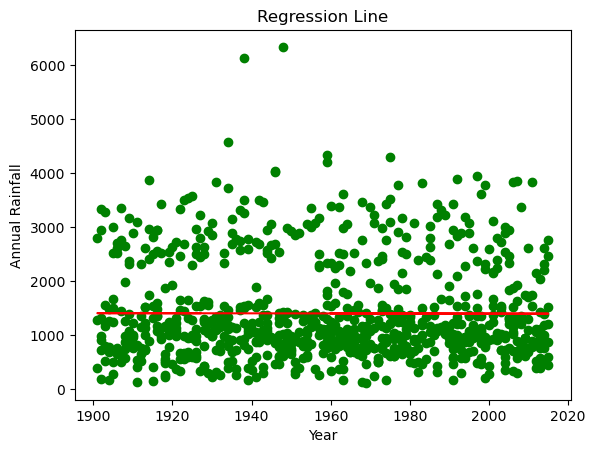

In [62]:
plt.scatter(X_test, y_test, color='green')
plt.plot(X_test, y_pred, color='red')
plt.xlabel("Year")
plt.ylabel("Annual Rainfall")
plt.title("Regression Line")
plt.show()

In [63]:
model.predict([[2020]])

C:\Users\OM\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1398.51650347])

In [64]:
model.score(X_test,y_test)

-0.0012567199871551527

In [65]:
i = model.intercept_
i

1577.7941239888155

In [67]:
c = model.coef_
c

array([-0.0887513])

In [68]:
c

array([-0.0887513])

In [25]:
# Predicted Rainfall = (-0.0887513 × YEAR) + intercept
-0.0887513*2020 + 1327.56

1148.282374

In [20]:
import seaborn as sns

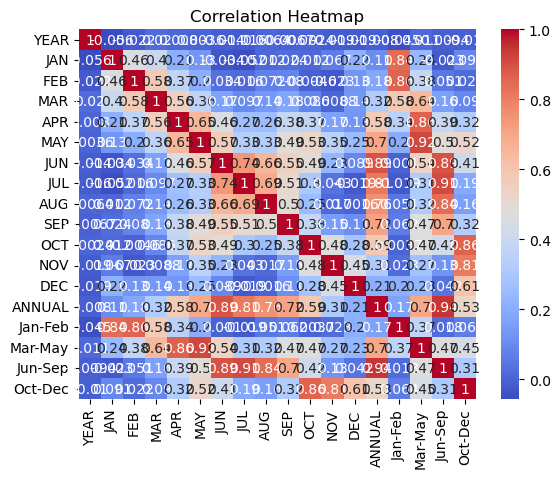

In [21]:
sns.heatmap(corr,annot = True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()